<a href="https://colab.research.google.com/github/NikhilaRaj7337/ML_Projects/blob/main/Project_2_BreastCancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Reference source code - https://github.com/bora-pajo/breast-cancer-prediction/blob/master/breast_cancer_clean.ipynb

#First import all the libraries needed

import numpy as np #for linear algebra
import pandas as pd #for chopping, processing
import csv #for opening csv files
%matplotlib inline
import matplotlib.pyplot as plt #for plotting the graphs
from sklearn.linear_model import LogisticRegression #for logistic regression
from sklearn.pipeline import Pipeline #to assemble steps for cross validation
from sklearn.preprocessing import PolynomialFeatures #for all the polynomial features
from sklearn import svm #for Support Vector Machines
from sklearn.neighbors import NearestNeighbors #for nearest neighbor classifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier #for decision tree classifier
from sklearn.naive_bayes import GaussianNB  #for naive bayes classifier
from scipy import stats #for statistical info
from sklearn.model_selection import train_test_split # to split the data in train and test
from sklearn.model_selection import KFold # for cross validation
from sklearn.model_selection import GridSearchCV  # for tuning hyper parameters
from sklearn.neighbors import KNeighborsClassifier  #for k-neighbor classifier
from sklearn import metrics  # for checking the accuracy
from time import time

In [ ]:
#To mount the dataset from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import the input file from local computer
path = '/content/drive/MyDrive/data_for breast cancer.csv'
with open(path, 'r') as file:
    data = file.read()

In [ ]:
#Loading the data
data = pd.read_csv('/content/drive/MyDrive/data_for breast cancer.csv') #giving the path of the dataset instead of the file name

#To know how many no.of cases and variables are present in dataset
data.shape

(569, 33)

In [ ]:
#Description of the dataset

#how many cases are included in the dataset
length = len(data)
#how many features are in the dataset
features = data.shape[1]-1 #data.shape[1] -will give column names which are features, we usually have 1 target column and other input columns, to get all input features column --data.shape[1]-1
# Number of malignant cases
malignant = len(data[data['diagnosis']=='M'])

#Number of benign cases
benign = len(data[data['diagnosis']=='B'])

#Rate of malignant tumors over all cases
rate = (float(malignant)/(length))*100
#Printing the summary of dataset
print("There are "+ str(len(data))+" cases in this dataset")
print("There are {}".format(features)+" features in this dataset")
print("There are {}".format(malignant)+" cases diagnosed as malignant tumor")
print("There are {}".format(benign)+" cases diagnosed as benign tumor")
print("The percentage of malignant cases is: {:.4f}%".format(rate))

There are 569 cases in this dataset
There are 32 features in this dataset
There are 212 cases diagnosed as malignant tumor
There are 357 cases diagnosed as benign tumor
The percentage of malignant cases is: 37.2583%


In [ ]:
#To retrieve unique values from diagnosis column
data.diagnosis.unique()

#drop ID because we do not need the ID number as shown above

data.drop('id',axis=1,inplace=True)
#check that dropped
data.head(2)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN


In [ ]:
#Extract all the features required to predict (starting from radius mean)
features = data.columns[1:30]
print(features)

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object')


In [ ]:
#We should predict the diagnosis in malignant and begnin, so we extract it as dependent variables
target = data.columns[0:1] #['diagnosis']
print(target)

Index(['diagnosis'], dtype='object')


In [ ]:
from re import X
#Seperating the data as features data and target data
X = data[features]
Y = data[target]

print(X.shape)
print(Y.shape)


(569, 29)
(569, 1)


In [ ]:
df = pd.DataFrame(data)

def preprocess_features(X):
    ''' Preprocesses the football data and converts catagorical variables into dummy variables. '''

    # Initialize new output DataFrame
    output = pd.DataFrame(index = X.index)

    #Investigate each feature column for the data
    for col, col_data in X.items():

        # If data type is categorical, convert to M/B to 0/1
        if col_data.dtype == object:
            col_data = col_data.replace(['M','B'], [1, 0])

        # collect revised columns
        output = output.join(col_data)

    return output

X = preprocess_features(X)
Y = Y.replace(['M', 'B'], [1,0])
print ("Processed feature columns ({} total features):\n{}".format(len(X.columns), list(X.columns)))
print ("Target columns ({} total features):\n{}".format(1, Y.columns))


Processed feature columns (29 total features):
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst']
Target columns (1 total features):
Index(['diagnosis'], dtype='object')


<ipython-input-10-889140647>:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace(['M', 'B'], [1,0])


In [ ]:
# import cross_validation to split the train and testing
# Set the number of training points
nr_train = 400
# Set the number of testing points
nr_test = X.shape[0] - nr_train

# Shuffle and split the dataset into the number of training and testing points above
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=nr_test, random_state=40)

# Show the results of the split
print ("Training set has {} samples.".format(X_train.shape[0]))
print ("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 400 samples.
Testing set has 169 samples.


In [ ]:
from sklearn.metrics import f1_score
def train_classifier(clf, X_train, Y_train):
    ''' Fits a classifier to the training data. '''

    # Start the clock, train the classifier, then stop the clock, to record the time
    start = time()
    clf.fit(X_train, Y_train)
    end = time()

    # Print the results
    print ("Trained model in {:.4f} seconds".format(end - start))


def predict_labels(clf, features, target):
    ''' Makes predictions using a fit classifier based on F1 score. '''

    # Start the clock, make predictions, then stop the clock
    start = time()
    Y_pred = clf.predict(features)
    end = time()

    # Print and return results
    print ("\nMade predictions in {:.4f} seconds.".format(end - start))
    return f1_score(target.values, Y_pred, pos_label=1)

def train_predict(clf, X_train, Y_train, X_test, Y_test):
    ''' Train and predict using a classifer based on F1 score. '''

    # Indicate the classifier and the training set size
    print ("Training a {} using a training set size of {}. . .".format(clf.__class__.__name__, len(X_train)))

    # Train the classifier
    train_classifier(clf, X_train, Y_train)

    # Print the results of prediction for both training and testing
    print ("F1 score for training set: {:.4f}.".format(predict_labels(clf, X_train, Y_train)))
    print ("\nF1 score for test set: {:.4f}.".format(predict_labels(clf, X_test, Y_test)))



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
clf_A = KNeighborsClassifier()
clf_B = DecisionTreeClassifier(random_state=0)
clf_C = SVC()
clf_D = GaussianNB()
clf_E = RandomForestClassifier(n_estimators=10)
clf_G = AdaBoostClassifier()
clf_H = MLPClassifier(alpha=1)

In [ ]:
X_train_100 = X_train[:100]
Y_train_100 = Y_train[:100]

X_train_200 = X_train[:200]
Y_train_200 = Y_train[:200]

X_train_300 = X_train[:300]
Y_train_300 = Y_train[:300]

X_train_300 = X_train[:400]
Y_train_300 = Y_train[:400]

In [ ]:
for clf in [clf_A, clf_B, clf_C, clf_D, clf_E, clf_G, clf_H]:
    for size in [300, 400]:
        train_predict(clf, X_train[:size], Y_train[:size], X_test, Y_test)
        #print ('/n')

Training a KNeighborsClassifier using a training set size of 300. . .
Trained model in 0.0053 seconds

Made predictions in 0.0573 seconds.
F1 score for training set: 0.9156.

Made predictions in 0.0127 seconds.

F1 score for test set: 0.8738.
Training a KNeighborsClassifier using a training set size of 400. . .
Trained model in 0.0025 seconds

Made predictions in 0.0221 seconds.
F1 score for training set: 0.9290.

Made predictions in 0.0111 seconds.

F1 score for test set: 0.9038.
Training a DecisionTreeClassifier using a training set size of 300. . .
Trained model in 0.0083 seconds

Made predictions in 0.0018 seconds.
F1 score for training set: 1.0000.

Made predictions in 0.0015 seconds.

F1 score for test set: 0.8654.
Training a DecisionTreeClassifier using a training set size of 400. . .
Trained model in 0.0101 seconds

Made predictions in 0.0014 seconds.
F1 score for training set: 1.0000.

Made predictions in 0.0013 seconds.

F1 score for test set: 0.9074.
Training a SVC using a t

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exampl

Trained model in 0.0342 seconds

Made predictions in 0.0039 seconds.
F1 score for training set: 0.9957.

Made predictions in 0.0038 seconds.

F1 score for test set: 0.9623.
Training a RandomForestClassifier using a training set size of 400. . .
Trained model in 0.0349 seconds

Made predictions in 0.0027 seconds.
F1 score for training set: 1.0000.

Made predictions in 0.0024 seconds.

F1 score for test set: 0.9159.
Training a AdaBoostClassifier using a training set size of 300. . .
Trained model in 0.1681 seconds

Made predictions in 0.0127 seconds.
F1 score for training set: 1.0000.

Made predictions in 0.0131 seconds.

F1 score for test set: 0.9720.
Training a AdaBoostClassifier using a training set size of 400. . .


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Trained model in 0.1830 seconds

Made predictions in 0.0127 seconds.
F1 score for training set: 1.0000.

Made predictions in 0.0157 seconds.

F1 score for test set: 0.9369.
Training a MLPClassifier using a training set size of 300. . .


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Trained model in 0.2732 seconds

Made predictions in 0.0089 seconds.
F1 score for training set: 0.9231.

Made predictions in 0.0026 seconds.

F1 score for test set: 0.9020.
Training a MLPClassifier using a training set size of 400. . .


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Trained model in 2.6033 seconds

Made predictions in 0.0023 seconds.
F1 score for training set: 0.9359.

Made predictions in 0.0020 seconds.

F1 score for test set: 0.9074.


In [ ]:
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
#from scipy.interpolate import interp
from scipy.interpolate import interp2d
import numpy as np
#from scipy.interpolate import interp1d

In [ ]:
Y_test.shape

(169, 1)

In [ ]:
# Uninstall the current version of ggplot
!pip uninstall ggplot -y
# Install the latest version of ggplot
!pip install ggplot

Found existing installation: ggplot 0.11.5
Uninstalling ggplot-0.11.5:
  Successfully uninstalled ggplot-0.11.5
  Using cached ggplot-0.11.5-py2.py3-none-any.whl.metadata (2.9 kB)
Using cached ggplot-0.11.5-py2.py3-none-any.whl (2.2 MB)


In [ ]:
!pip install plotnine

In [ ]:
from sklearn.datasets import make_classification
from sklearn import metrics
import pandas as pd
from plotnine import ggplot, aes, geom_line, geom_abline, ggtitle, theme_minimal
from plotnine.geoms import geom_area
import matplotlib.pyplot as plt

In [ ]:
# Get predicted probabilities for ROC
preds = clf_D.predict_proba(X_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(Y_test, preds)

#fpr, tpr, _ = roc_curve(Y_test, y_probs)
roc_auc = metrics.auc(fpr, tpr)

# Create DataFrame for plotting
df = pd.DataFrame({'fpr': fpr, 'tpr': tpr})

# Calculate AUC
auc_score = metrics.auc(fpr, tpr)

# Create the plot
roc_plot = (
    ggplot(df, aes(x='fpr', y='tpr')) +
    geom_line(color="blue") +
    geom_abline(linetype='dashed', color='grey') +
    ggtitle(f"ROC for Naive Bayes (AUC = {auc_score:.2f})") +
    theme_minimal()
)

print(roc_plot)
fig = roc_plot.draw()
plt.show()

<ggplot: (640 x 480)>


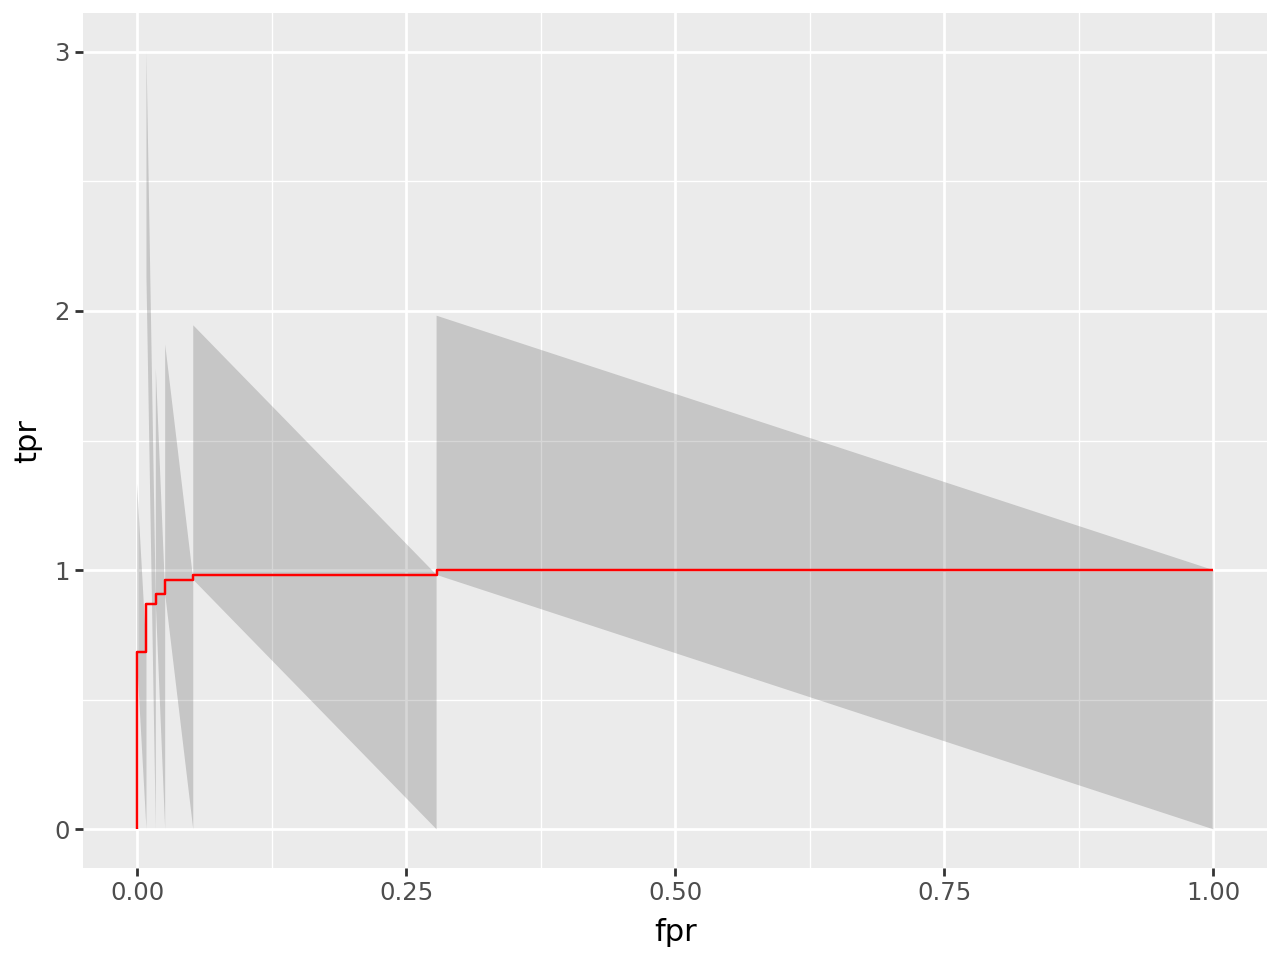

In [ ]:
auc = metrics.auc(fpr,tpr)
ggplot(df, aes(x='fpr', y='tpr')) + geom_area(alpha=0.2) + geom_line(color = 'red')

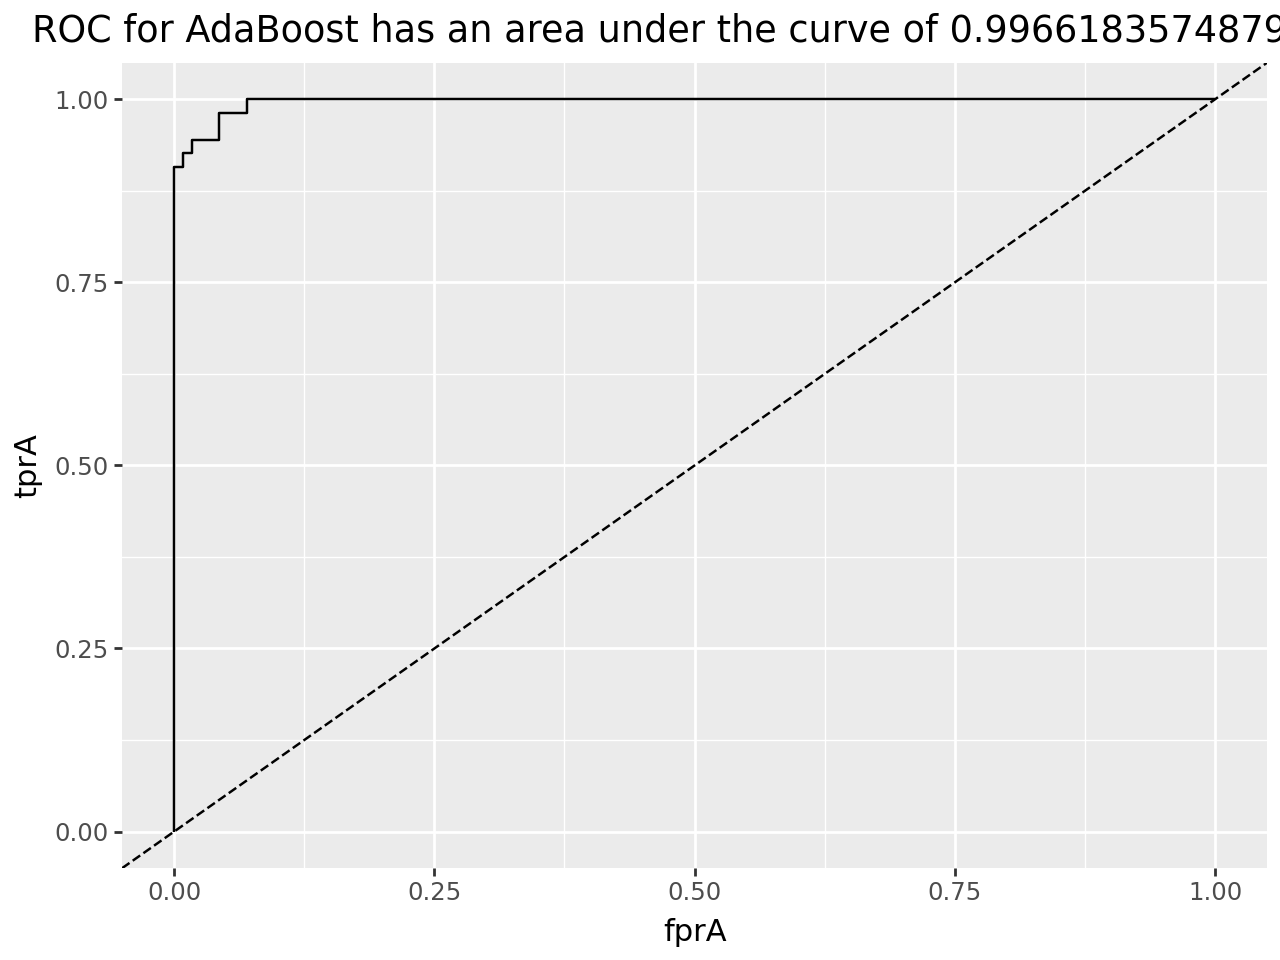

In [ ]:
preds = clf_G.predict_proba(X_test)[:,1]
fprA, tprA, _ = metrics.roc_curve(Y_test, preds)

df = pd.DataFrame({'fprA' : fprA, 'tprA' : tprA})
ggplot(df, aes(x='fprA', y='tprA')) +\
    geom_line() +\
    geom_abline(linetype='dashed')+\
    ggtitle ("ROC for AdaBoost has an area under the curve of " + str(metrics.auc(fprA,tprA)))



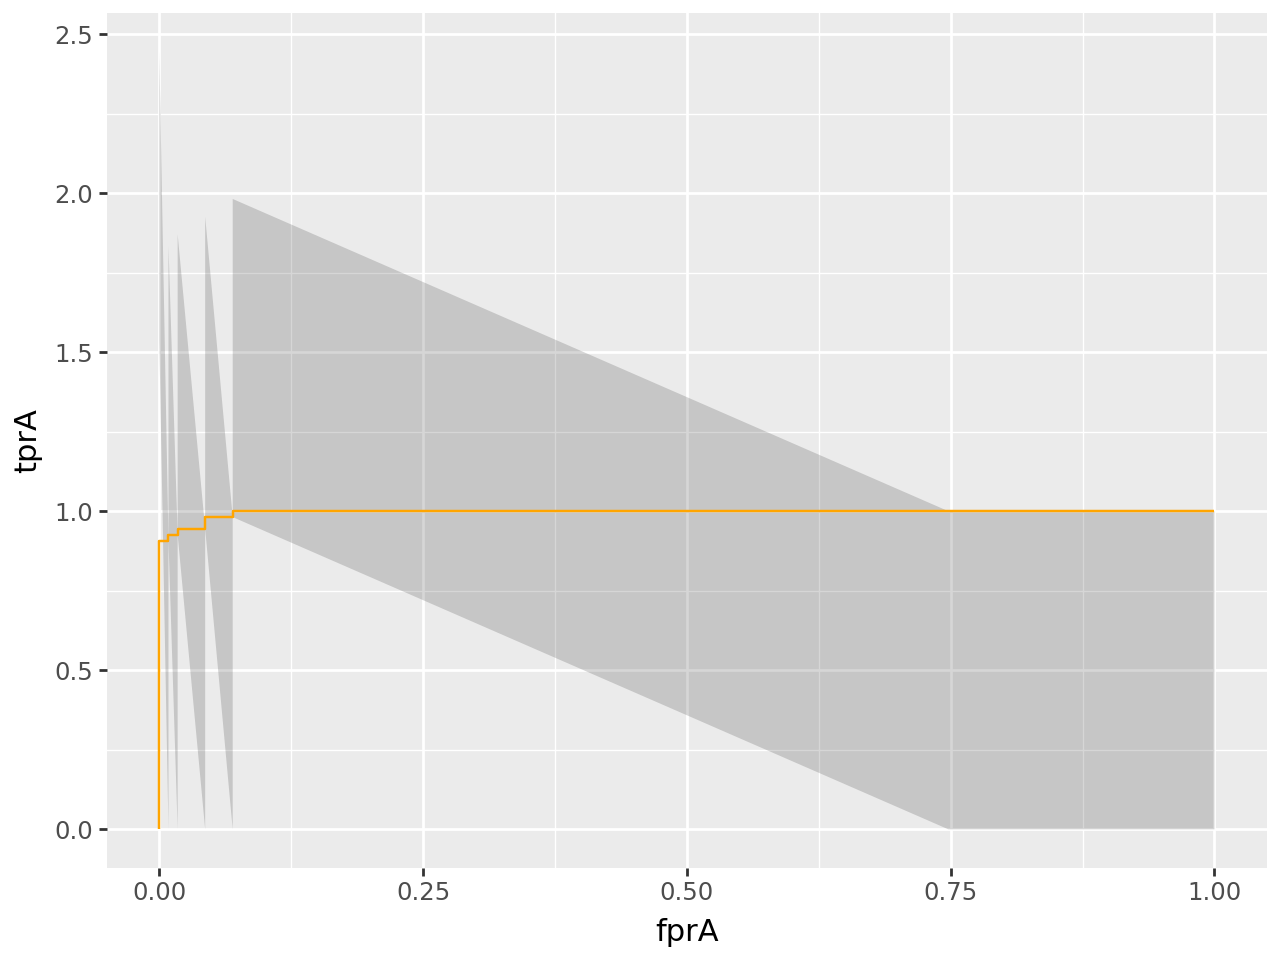

In [ ]:
auc = metrics.auc(fprA,tprA)
ggplot(df, aes(x='fprA', y='tprA')) + geom_area(alpha=0.2) + geom_line(colour = 'orange')

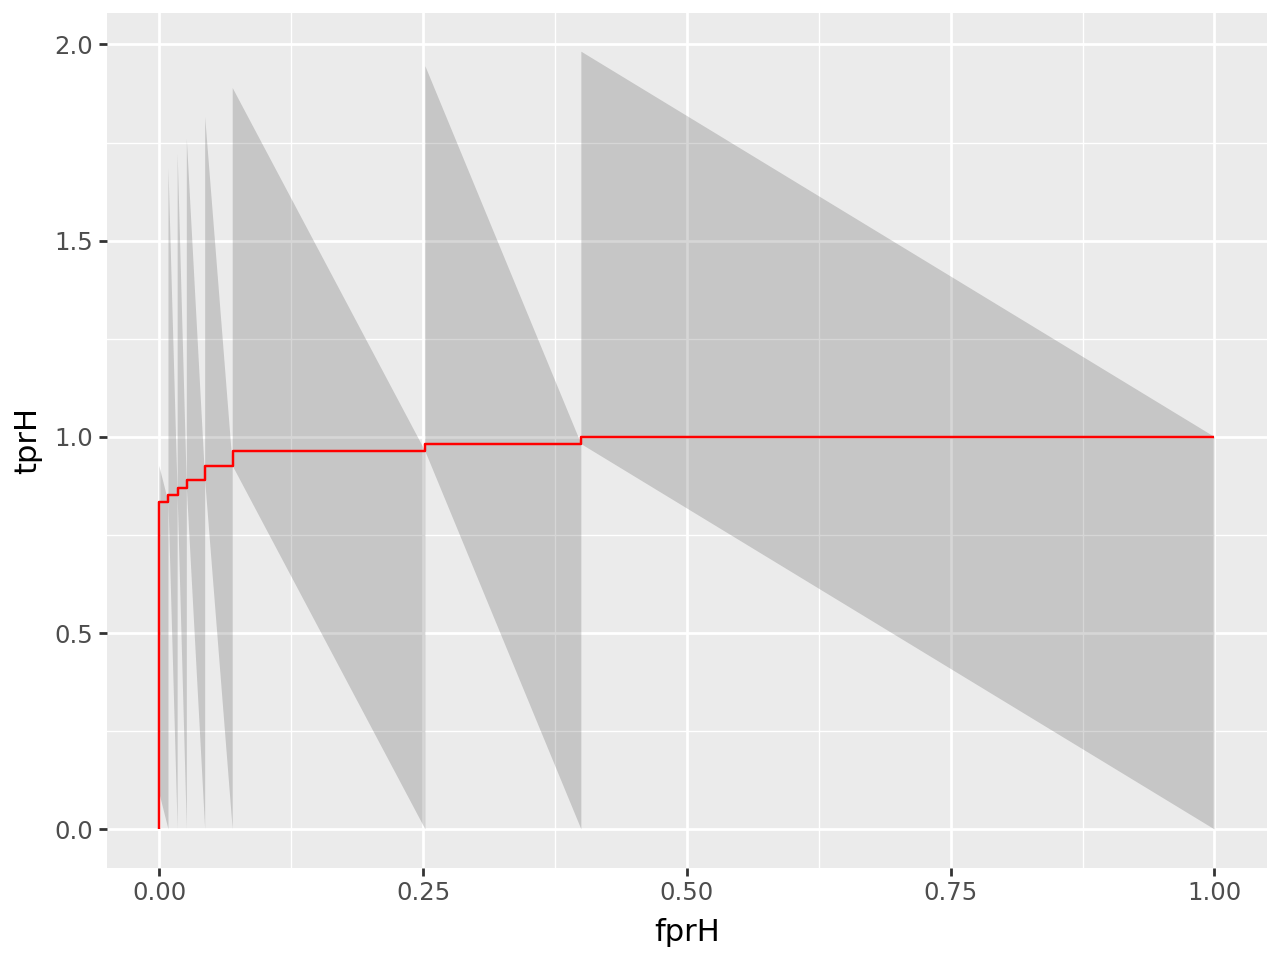

In [ ]:
auc = metrics.auc(fprH,tprH)
ggplot(df, aes(x='fprH', y='tprH')) + geom_area(alpha=0.2) + geom_line(color = 'red')

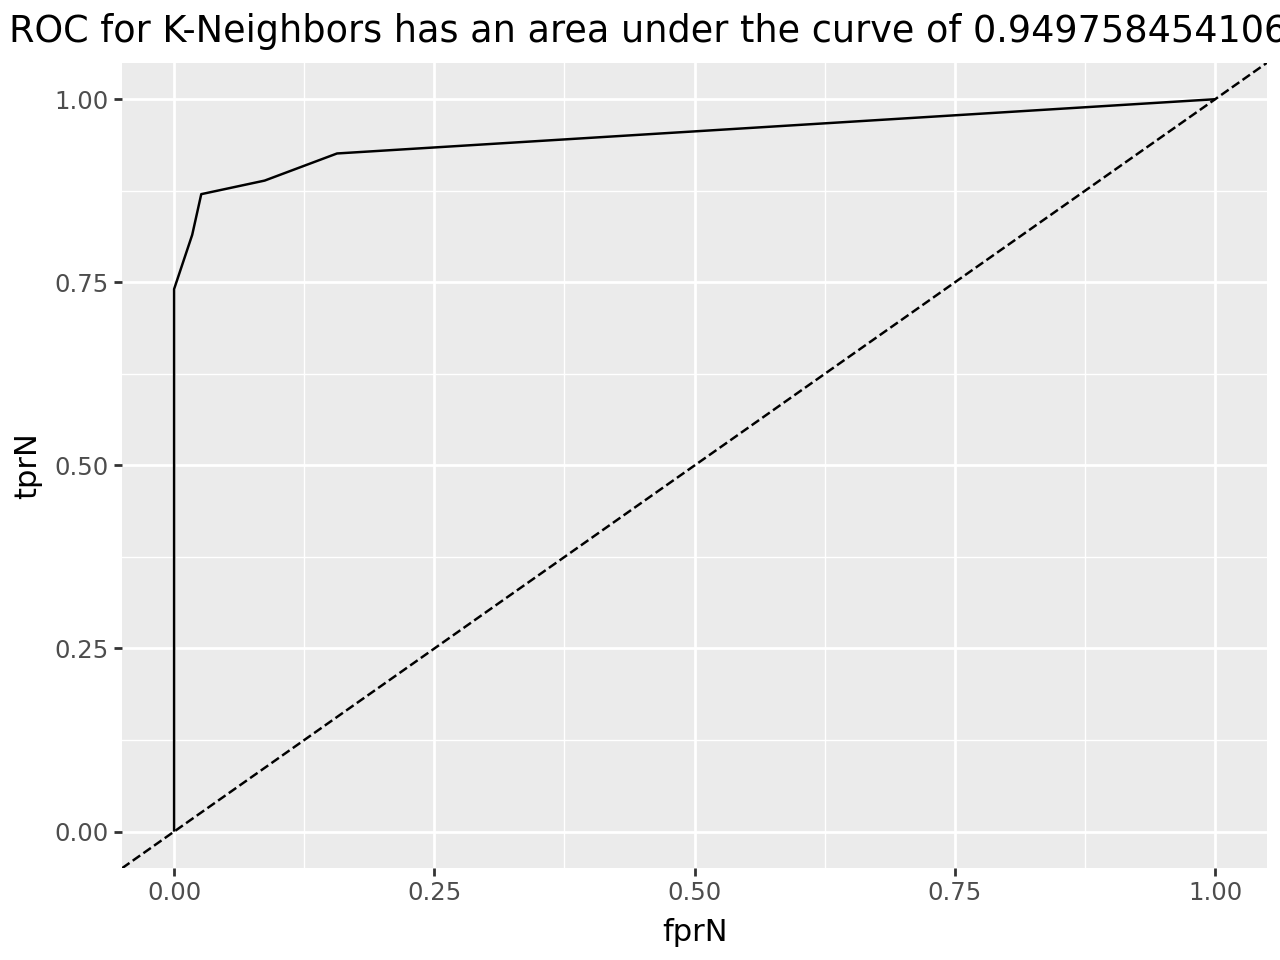

In [ ]:
# ROC curve for K-Neighbors
preds = clf_A.predict_proba(X_test)[:,1]
fprN, tprN, _ = metrics.roc_curve(Y_test, preds)

df = pd.DataFrame(dict(fprN=fprN, tprN=tprN))
ggplot(df, aes(x='fprN', y='tprN')) +\
    geom_line() +\
    geom_abline(linetype='dashed')+\
    ggtitle ("ROC for K-Neighbors has an area under the curve of " + str(metrics.auc(fprN,tprN)))

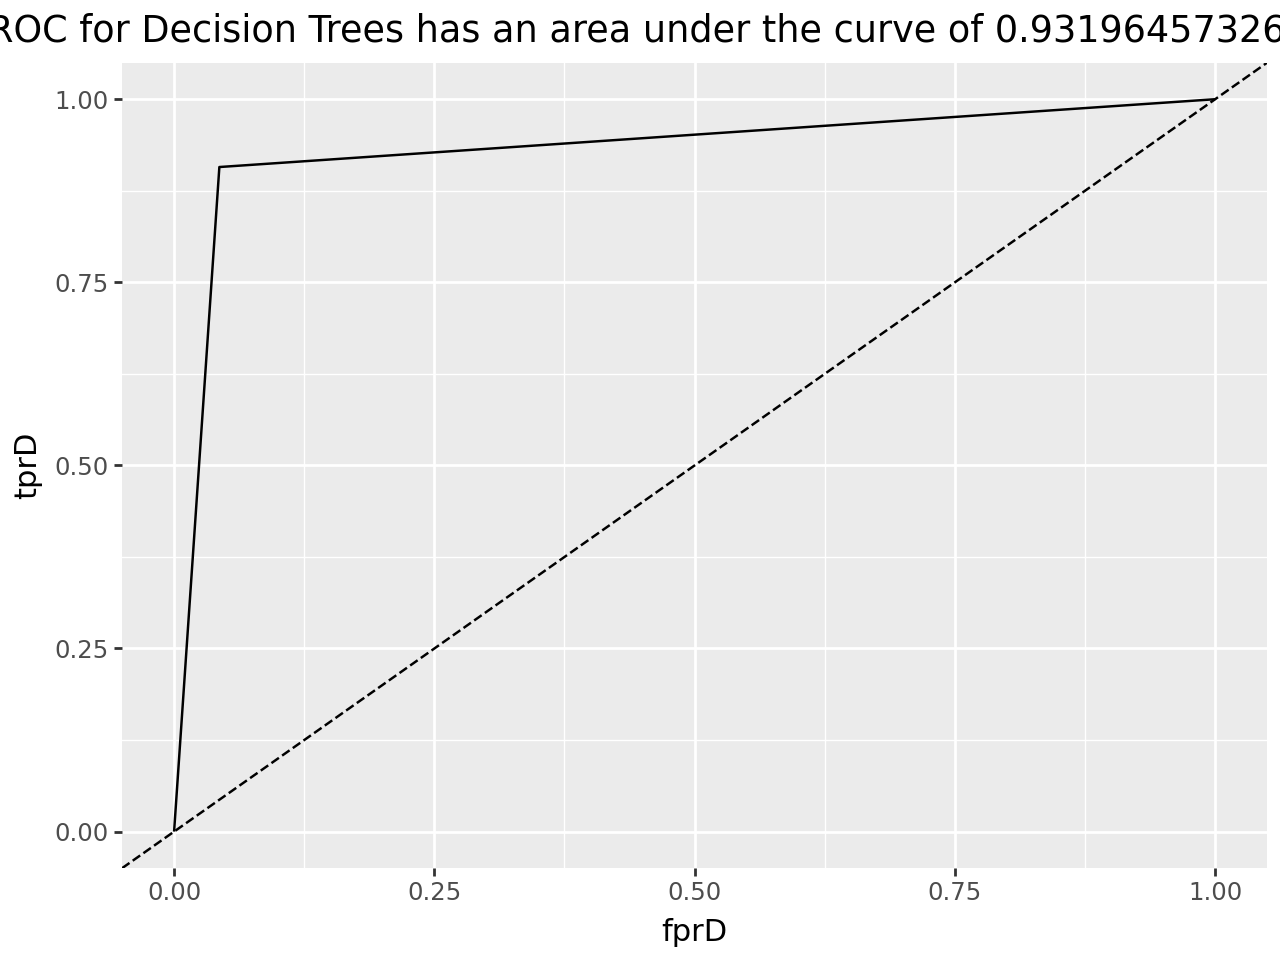

In [ ]:
# ROC curve for Decision trees
preds = clf_B.predict_proba(X_test)[:,1]
fprD, tprD, _ = metrics.roc_curve(Y_test, preds)

df = pd.DataFrame(dict(fprD=fprD, tprD=tprD))
ggplot(df, aes(x='fprD', y='tprD')) +\
    geom_line() +\
    geom_abline(linetype='dashed')+\
    ggtitle ("ROC for Decision Trees has an area under the curve of " + str(metrics.auc(fprD,tprD)))

In [ ]:
# Set the number of training points much smaller than before
nr_train = 50
# Set the number of testing points
nr_test = X.shape[0] - nr_train

# Shuffle and split the dataset into the number of training and testing points above
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=nr_test, random_state=30)

# Show the results of the split
print ("Training set has {} samples.".format(X_train.shape[0]))
print ("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 50 samples.
Testing set has 519 samples.


In [ ]:
for clf in [clf_D, clf_G, clf_H]:
    for size in [50]:
        train_predict(clf, X_train[:size], Y_train[:size], X_test, Y_test)
        print ('/n')

Training a GaussianNB using a training set size of 50. . .
Trained model in 0.0215 seconds

Made predictions in 0.0196 seconds.
F1 score for training set: 0.9048.

Made predictions in 0.0147 seconds.

F1 score for test set: 0.9215.
/n
Training a AdaBoostClassifier using a training set size of 50. . .


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


Trained model in 0.9189 seconds

Made predictions in 0.0487 seconds.
F1 score for training set: 1.0000.

Made predictions in 0.0194 seconds.

F1 score for test set: 0.9255.
/n
Training a MLPClassifier using a training set size of 50. . .
Trained model in 0.1712 seconds

Made predictions in 0.0027 seconds.
F1 score for training set: 0.9500.

Made predictions in 0.0023 seconds.

F1 score for test set: 0.8382.
/n


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


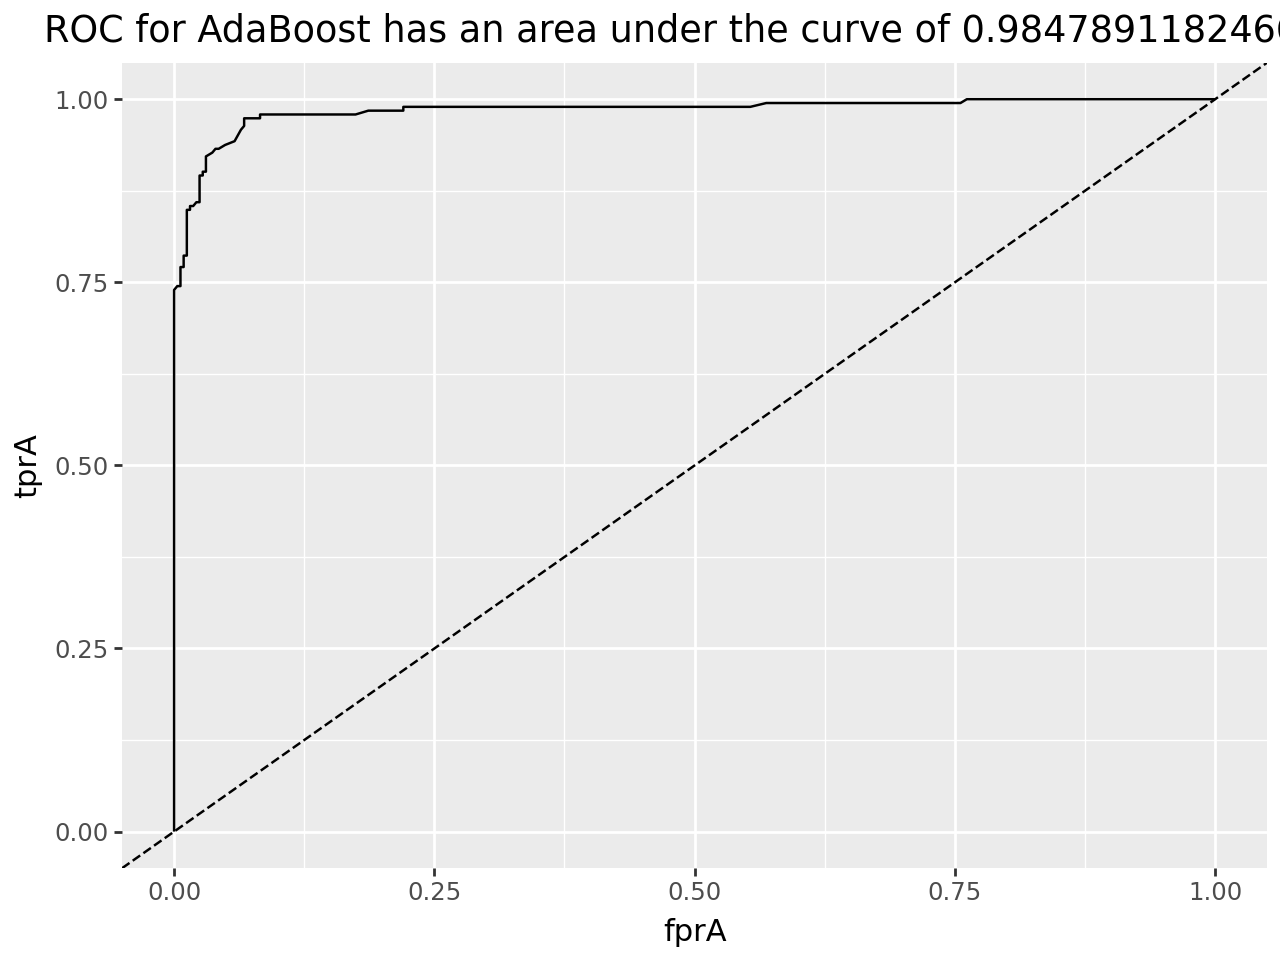

In [ ]:
# ROC curve for AdaBoost
preds = clf_G.predict_proba(X_test)[:,1]
fprA, tprA, _ = metrics.roc_curve(Y_test, preds)

df = pd.DataFrame(dict(fprA=fprA, tprA=tprA))
ggplot(df, aes(x='fprA', y='tprA')) +\
    geom_line() +\
    geom_abline(linetype='dashed')+\
    ggtitle ("ROC for AdaBoost has an area under the curve of " + str(metrics.auc(fprA,tprA)))


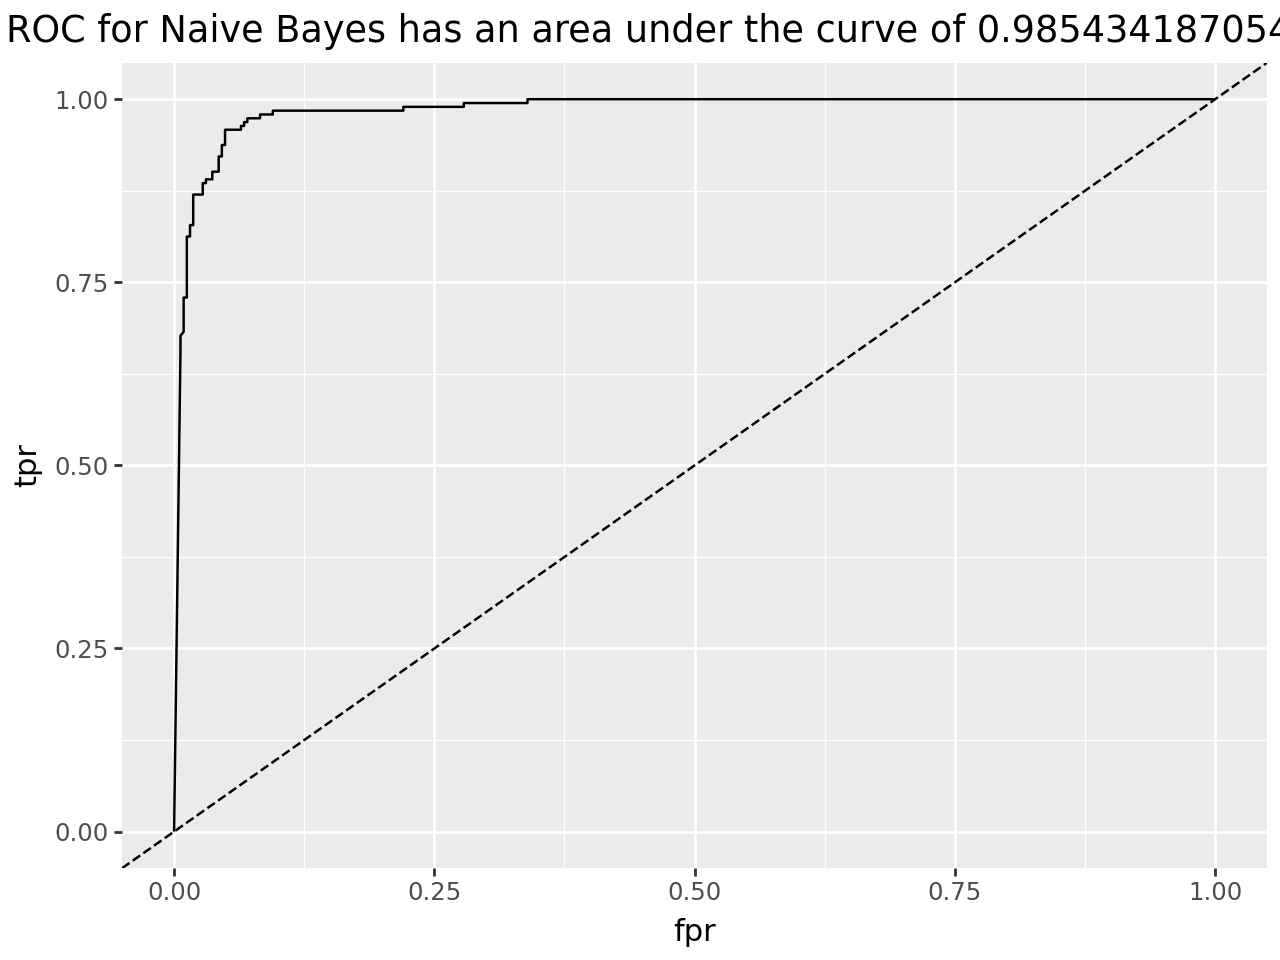

In [ ]:
# ROC curve for Naive Bayes
preds = clf_D.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(Y_test, preds)

df = pd.DataFrame(dict(fpr=fpr, tpr=tpr))
ggplot(df, aes(x='fpr', y='tpr')) +\
    geom_line() +\
    geom_abline(linetype='dashed')+\
    ggtitle ("ROC for Naive Bayes has an area under the curve of " + str(metrics.auc(fpr,tpr)))